Computing OPT predictive ...
  ∫OPT ≈ 1.0002
Computing APT predictive ...
  ∫APT ≈ 1.0001


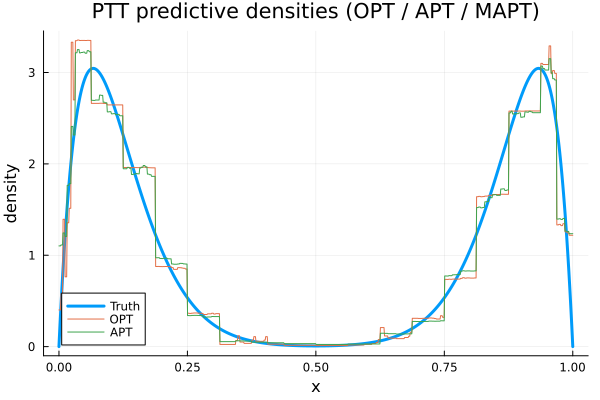

In [1]:
# --- Minimal predictive-only wrappers for PTT (APT / OPT / MAPT) ---

import Pkg
for pkg in ("RCall","Distributions","Plots","Random")
    try
        @eval using $(Symbol(pkg))
    catch
        Pkg.add(pkg); @eval using $(Symbol(pkg))
    end
end

# Install + load PTT
R"""
if (!requireNamespace("remotes", quietly=TRUE))
  install.packages("remotes", repos="https://cloud.r-project.org")
if (!requireNamespace("PTT", quietly=TRUE)) {
  remotes::install_github("MaStatLab/PTT")
}
library(PTT)
"""

# ---------- predictive density helpers (exactly mirroring the example API) ----------

# APT predictive density: apt(X=..., Xpred=..., max.resol=..., rho0=0.2)$pred
apt_pred_density(X::AbstractVector{<:Real}, grid::AbstractVector{<:Real};
                 max_resol::Int=8, rho0::Real=0.2)::Vector{Float64} = begin
    R"""
    res  <- apt(X = $X, Xpred = $grid, max.resol = $max_resol, rho0 = $rho0)
    pred <- as.numeric(res$pred)
    """
    rcopy(Vector{Float64}, R"pred")
end

# OPT predictive density (same calling shape)
opt_pred_density(X::AbstractVector{<:Real}, grid::AbstractVector{<:Real};
                 max_resol::Int=8, rho0::Real=0.2)::Vector{Float64} = begin
    R"""
    res  <- opt(X = $X, Xpred = $grid, max.resol = $max_resol, rho0 = $rho0)
    pred <- as.numeric(res$pred)
    """
    rcopy(Vector{Float64}, R"pred")
end

# Markov APT predictive density; function name can be `mapt` or `markov.apt`
mapt_pred_density(X::AbstractVector{<:Real}, grid::AbstractVector{<:Real};
                  max_resol::Int=8, rho0::Real=0.2)::Vector{Float64} = begin
    R"""
    if (exists("mapt")) {
      res <- mapt(X = $X, Xpred = $grid, max.resol = $max_resol, rho0 = $rho0)
    } else if (exists("markov.apt")) {
      res <- markov.apt(X = $X, Xpred = $grid, max.resol = $max_resol, rho0 = $rho0)
    } else {
      stop("No Markov APT function found in PTT (tried mapt / markov.apt).")
    }
    pred <- as.numeric(res$pred)
    """
    rcopy(Vector{Float64}, R"pred")
end

# ---------- quick smoke test on [0,1] ----------

using Random, Distributions, Plots
Random.seed!(1234); R"set.seed(1234)"

n      = 600
mix    = MixtureModel([Beta(2,15), Beta(15,2)], [0.5, 0.5])
X      = rand(mix, n)
xgrid  = collect(LinRange(1e-6, 1-1e-6, 1000))
truth  = pdf.(mix, xgrid)
Δx     = xgrid[2] - xgrid[1]
max_resol = 8  # adjust as you like

dens = Dict{Symbol,Vector{Float64}}()

println("Computing OPT predictive ...")
try
    dens[:OPT]  = opt_pred_density(X, xgrid; max_resol=max_resol, rho0=0.2)
    println("  ∫OPT ≈ ", round(sum(dens[:OPT])*Δx, digits=4))
catch e
    @warn "OPT predictive failed: $e"
end

println("Computing APT predictive ...")
try
    dens[:APT]  = apt_pred_density(X, xgrid; max_resol=max_resol, rho0=0.2)
    println("  ∫APT ≈ ", round(sum(dens[:APT])*Δx, digits=4))
catch e
    @warn "APT predictive failed: $e"
end


# Plot truth + available predictives
p = plot(xgrid, truth, lw=3, label="Truth", xlabel="x", ylabel="density",
         title="PTT predictive densities (OPT / APT / MAPT)")
for m in (:OPT, :APT, :MAPT)
    haskey(dens, m) && plot!(xgrid, dens[m], label=String(m))
end
display(p)
